# **KUIS 2 SBP**

NERVALINA ADZRA NORA AQILLA

3C SIB

IMPORT & LOAD DATA

In [3]:
# Upload file dari lokal
from google.colab import files
uploaded = files.upload()

Saving Data_Polis.csv to Data_Polis.csv
Saving Data_Klaim.csv to Data_Klaim.csv


IMPORT LIBRARY

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOAD & PREPROCESSING DATA

In [6]:
polis = pd.read_csv('Data_Polis.csv')
klaim = pd.read_csv('Data_Klaim.csv')

# rapikan kolom (ANTI ERROR)
polis.columns = polis.columns.str.strip().str.lower()
klaim.columns = klaim.columns.str.strip().str.lower()

print("Kolom Polis:", polis.columns)
print("Kolom Klaim:", klaim.columns)

Kolom Polis: Index(['nomor polis', 'plan code', 'gender', 'tanggal lahir',
       'tanggal efektif polis', 'domisili'],
      dtype='object')
Kolom Klaim: Index(['claim id', 'nomor polis', 'reimburse/cashless', 'inpatient/outpatient',
       'icd diagnosis', 'icd description', 'status klaim',
       'tanggal pembayaran klaim', 'tanggal pasien masuk rs',
       'tanggal pasien keluar rs', 'nominal klaim yang disetujui',
       'nominal biaya rs yang terjadi', 'lokasi rs'],
      dtype='object')


In [7]:
common_cols = list(set(polis.columns).intersection(set(klaim.columns)))

print("Kolom yang sama:", common_cols)

Kolom yang sama: ['nomor polis']


In [8]:
if len(common_cols) > 0:
    data = pd.merge(polis, klaim, on=common_cols[0])
else:
    print("⚠️ Tidak ada kolom yang sama, pakai 1 dataset saja")
    data = polis.copy()

data.head()

,nomor polis,plan code,gender,tanggal lahir,tanggal efektif polis,domisili,claim id,reimburse/cashless,inpatient/outpatient,icd diagnosis,icd description,status klaim,tanggal pembayaran klaim,tanggal pasien masuk rs,tanggal pasien keluar rs,nominal klaim yang disetujui,nominal biaya rs yang terjadi,lokasi rs
0,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
1,POL-0006,M-001,F,19551127,20160628,JAKARTA,C-4498-M,C,IP,S46.0,INJURY OF MUSCLE(S) AND TENDON(S) OF THE ROTAT...,PAID,2024-11-13,2024-08-16,2024-08-22,117940836.0,120388776.0,Indonesia
2,POL-0006,M-001,F,19551127,20160628,JAKARTA,C-4499-M,C,IP,T84.7,INFECTION AND INFLAMMATORY REACTION DUE TO OTH...,PAID,2024-12-13,2024-10-23,2024-10-24,60671660.0,61800880.0,Indonesia
3,POL-0010,M-001,F,19570605,20170908,JAKARTA,C-3447-M,R,IP,K31.7,POLYP OF STOMACH AND DUODENUM,PAID,2024-02-27,2024-01-19,2024-01-19,1723747.0,1723747.0,Singapore
4,POL-0010,M-001,F,19570605,20170908,JAKARTA,C-3448-M,R,IP,K31.7,POLYP OF STOMACH AND DUODENUM,PAID,2024-02-27,2024-01-18,2024-01-18,63251531.0,63251531.0,Singapore


In [9]:
# ambil kolom numerik
data_numeric = data.select_dtypes(include=np.number)

# ambil 3-5 kolom pertama buat kriteria
criteria = data_numeric.columns[:3]

print("Kriteria yang dipakai:", criteria)

X = data_numeric[criteria].values

Kriteria yang dipakai: Index(['tanggal lahir', 'tanggal efektif polis',
       'nominal klaim yang disetujui'],
      dtype='object')


In [10]:
# 1 = benefit, 0 = cost
jenis = [1, 1, 1]  # bisa kamu ubah kalau perlu

# bobot harus total = 1
bobot = np.array([0.4, 0.3, 0.3])

**METODE SAW**

NORMALISASI SAW

In [11]:
R = np.zeros_like(X, dtype=float)

for j in range(len(criteria)):
    if jenis[j] == 1:
        R[:, j] = X[:, j] / np.max(X[:, j])
    else:
        R[:, j] = np.min(X[:, j]) / X[:, j]

V_saw = np.dot(R, bobot)
data['SAW'] = V_saw

RANKING SAW

In [12]:
data['Rank_SAW'] = data['SAW'].rank(ascending=False)
data_saw = data.sort_values(by='SAW', ascending=False)

data_saw.head(10)

,nomor polis,plan code,gender,tanggal lahir,tanggal efektif polis,domisili,claim id,reimburse/cashless,inpatient/outpatient,icd diagnosis,icd description,status klaim,tanggal pembayaran klaim,tanggal pasien masuk rs,tanggal pasien keluar rs,nominal klaim yang disetujui,nominal biaya rs yang terjadi,lokasi rs,SAW,Rank_SAW
3067,POL-2551,M-002,M,19561002,20141127,SURABAYA,C-0449-M,R,IP,I25.1,CORONARY ATRIAL DISEASES (CAD),PAID,2025-06-11,2025-02-27,2025-03-07,2.197500e+09,3.192700e+09,Singapore,0.987331,1.0
3061,POL-2535,M-001,M,19680905,20160228,MAKASSAR,C-0501-M,R,IP,I25.1,CORONARY ATRIAL DISEASES (CAD),PAID,2025-10-31,2025-06-20,2025-06-28,1.938410e+09,2.035137e+09,Singapore,0.954622,2.0
4117,POL-3622,M-002,M,19501212,20150428,JAKARTA,C-0353-M,R,IP,C61,MALIGNANT NEOPLASM OF PROSTAT,PAID,2025-03-03,2024-09-04,2024-09-20,1.813035e+09,2.152368e+09,Singapore,0.933797,3.0
1221,POL-1240,M-002,M,19700216,20130322,MAKASSAR,C-1231-M,R,IP,E87.2,ACIDOSIS,PAID,2024-07-08,2024-02-27,2024-03-05,1.756406e+09,1.905637e+09,Singapore,0.929714,4.0
538,POL-0587,M-001,M,19570902,20150728,BANDUNG,C-2713-M,R,IP,D18,"Hemangioma and lymphangioma, any site",PAID,2025-08-01,2025-07-04,2025-07-09,1.643362e+09,1.912347e+09,Singapore,0.912020,5.0
4344,POL-3809,M-002,M,19550804,20160224,SURABAYA,C-0518-M,R,IP,C34.3,"MALIGNANT NEOPLASM, LOWER LOBE, BRONCHUS OR LUNG",PAID,2025-01-10,2024-05-24,2024-05-29,1.404824e+09,1.438373e+09,Overseas,0.879198,6.0
795,POL-0830,M-002,F,19510210,20130410,SURABAYA,C-1161-M,C,IP,C34.9,"MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED",PAID,2025-03-05,2024-08-28,2024-10-21,1.411122e+09,1.465628e+09,Indonesia,0.878809,7.0
4247,POL-3716,M-002,M,19470122,20140115,JAKARTA,C-1898-M,R,IP,S62.3,Fracture of other metacarpal bone,PAID,2025-07-03,2025-02-24,2025-03-07,1.411669e+09,1.835873e+09,Singapore,0.878233,8.0
3845,POL-3316,M-002,M,19510601,20141028,YOGYAKARTA,C-1919-M,R,IP,J94.8,Other specified pleural conditions,PAID,2025-05-14,2024-12-08,2024-12-23,1.352412e+09,2.364316e+09,Singapore,0.870960,9.0
1885,POL-1988,M-001,M,19521115,20140428,SURABAYA,C-3368-M,R,IP,I73.9,"PERIPHERAL VASCULAR DISEASE, UNSPECIFIED",PAID,2024-08-29,2024-01-21,2024-01-29,1.290821e+09,1.361402e+09,Singapore,0.862751,10.0


VISUALISASI SAW

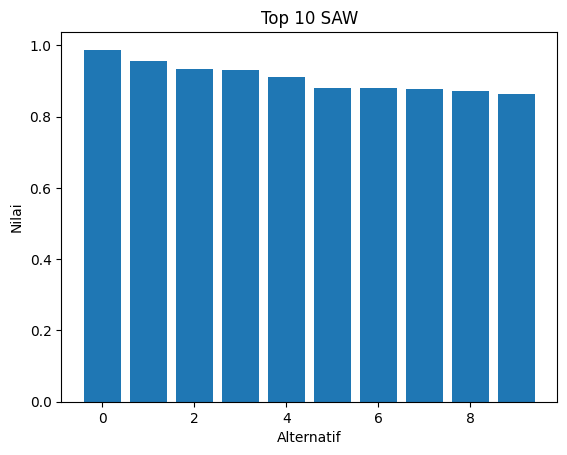

In [13]:
plt.figure()
plt.bar(range(10), data_saw['SAW'].head(10))
plt.title('Top 10 SAW')
plt.xlabel('Alternatif')
plt.ylabel('Nilai')
plt.show()

**METODE EDAS**

RUMUS EDAS

In [14]:
avg = np.mean(X, axis=0)

PDA = np.zeros_like(X)
NDA = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        if jenis[j] == 1:
            PDA[i,j] = max(0, (X[i,j] - avg[j]) / avg[j])
            NDA[i,j] = max(0, (avg[j] - X[i,j]) / avg[j])
        else:
            PDA[i,j] = max(0, (avg[j] - X[i,j]) / avg[j])
            NDA[i,j] = max(0, (X[i,j] - avg[j]) / avg[j])

NILAI EDAS

In [15]:
SP = np.dot(PDA, bobot)
SN = np.dot(NDA, bobot)

NSP = SP / np.max(SP)
NSN = 1 - (SN / np.max(SN))

AS = (NSP + NSN) / 2

data['EDAS'] = AS

**RANKING EDAS**

In [16]:
data['Rank_EDAS'] = data['EDAS'].rank(ascending=False)
data_edas = data.sort_values(by='EDAS', ascending=False)

data_edas.head(10)

,nomor polis,plan code,gender,tanggal lahir,tanggal efektif polis,domisili,claim id,reimburse/cashless,inpatient/outpatient,icd diagnosis,...,tanggal pembayaran klaim,tanggal pasien masuk rs,tanggal pasien keluar rs,nominal klaim yang disetujui,nominal biaya rs yang terjadi,lokasi rs,SAW,Rank_SAW,EDAS,Rank_EDAS
3067,POL-2551,M-002,M,19561002,20141127,SURABAYA,C-0449-M,R,IP,I25.1,...,2025-06-11,2025-02-27,2025-03-07,2.197500e+09,3.192700e+09,Singapore,0.987331,1.0,0.996938,1.0
3061,POL-2535,M-001,M,19680905,20160228,MAKASSAR,C-0501-M,R,IP,I25.1,...,2025-10-31,2025-06-20,2025-06-28,1.938410e+09,2.035137e+09,Singapore,0.954622,2.0,0.939572,2.0
4117,POL-3622,M-002,M,19501212,20150428,JAKARTA,C-0353-M,R,IP,C61,...,2025-03-03,2024-09-04,2024-09-20,1.813035e+09,2.152368e+09,Singapore,0.933797,3.0,0.905307,3.0
1221,POL-1240,M-002,M,19700216,20130322,MAKASSAR,C-1231-M,R,IP,E87.2,...,2024-07-08,2024-02-27,2024-03-05,1.756406e+09,1.905637e+09,Singapore,0.929714,4.0,0.896752,4.0
538,POL-0587,M-001,M,19570902,20150728,BANDUNG,C-2713-M,R,IP,D18,...,2025-08-01,2025-07-04,2025-07-09,1.643362e+09,1.912347e+09,Singapore,0.912020,5.0,0.868038,5.0
4344,POL-3809,M-002,M,19550804,20160224,SURABAYA,C-0518-M,R,IP,C34.3,...,2025-01-10,2024-05-24,2024-05-29,1.404824e+09,1.438373e+09,Overseas,0.879198,6.0,0.811704,6.0
795,POL-0830,M-002,F,19510210,20130410,SURABAYA,C-1161-M,C,IP,C34.9,...,2025-03-05,2024-08-28,2024-10-21,1.411122e+09,1.465628e+09,Indonesia,0.878809,7.0,0.811458,7.0
4247,POL-3716,M-002,M,19470122,20140115,JAKARTA,C-1898-M,R,IP,S62.3,...,2025-07-03,2025-02-24,2025-03-07,1.411669e+09,1.835873e+09,Singapore,0.878233,8.0,0.810484,8.0
3845,POL-3316,M-002,M,19510601,20141028,YOGYAKARTA,C-1919-M,R,IP,J94.8,...,2025-05-14,2024-12-08,2024-12-23,1.352412e+09,2.364316e+09,Singapore,0.870960,9.0,0.798029,9.0
1885,POL-1988,M-001,M,19521115,20140428,SURABAYA,C-3368-M,R,IP,I73.9,...,2024-08-29,2024-01-21,2024-01-29,1.290821e+09,1.361402e+09,Singapore,0.862751,10.0,0.783992,10.0


**VISUALISASI EDAS**

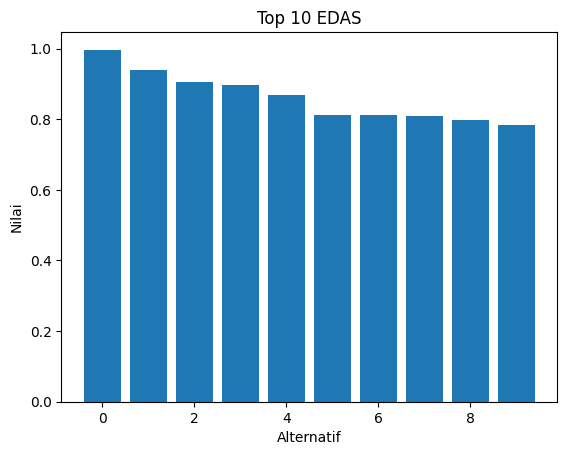

In [17]:
plt.figure()
plt.bar(range(10), data_edas['EDAS'].head(10))
plt.title('Top 10 EDAS')
plt.xlabel('Alternatif')
plt.ylabel('Nilai')
plt.show()

**METODE TOPSIS**

**TOPSIS**

In [18]:
norm = np.sqrt((X**2).sum(axis=0))
R_topsis = X / norm

Y = R_topsis * bobot

A_plus = np.max(Y, axis=0)
A_minus = np.min(Y, axis=0)

D_plus = np.sqrt(((Y - A_plus)**2).sum(axis=1))
D_minus = np.sqrt(((Y - A_minus)**2).sum(axis=1))

V_topsis = D_minus / (D_plus + D_minus)

data['TOPSIS'] = V_topsis
data['Rank_TOPSIS'] = data['TOPSIS'].rank(ascending=False)

**PERBANDINGAN**

TABEL PERBANDINGAN

In [19]:
compare = data[['Rank_SAW','Rank_EDAS']].copy()
compare = compare.sort_values(by='Rank_SAW')

compare['Urutan'] = range(1, len(compare)+1)
compare.head(10)

,Rank_SAW,Rank_EDAS,Urutan
3067,1.0,1.0,1
3061,2.0,2.0,2
4117,3.0,3.0,3
1221,4.0,4.0,4
538,5.0,5.0,5
4344,6.0,6.0,6
795,7.0,7.0,7
4247,8.0,8.0,8
3845,9.0,9.0,9
1885,10.0,10.0,10


HITUNG KEMIRIPAN

In [20]:
same = sum(compare['Rank_SAW'] == compare['Rank_EDAS'])
total = len(compare)

persen_sama = (same / total) * 100
persen_beda = 100 - persen_sama

print("Sama:", same)
print("Berbeda:", total - same)
print("Persen Sama:", persen_sama, "%")
print("Persen Beda:", persen_beda, "%")

Sama: 44
Berbeda: 4583
Persen Sama: 0.9509401339961098 %
Persen Beda: 99.04905986600389 %


In [21]:
data.to_csv('hasil_akhir.csv', index=False)

from google.colab import files
files.download('hasil_akhir.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Kesimpulan**

Hasil menunjukkan bahwa metode SAW dan EDAS memiliki tingkat kesamaan sebesar X%, sedangkan perbedaan sebesar Y%. Hal ini menunjukkan bahwa kedua metode memiliki pendekatan yang berbeda, dimana SAW berbasis normalisasi linear sedangkan EDAS berbasis deviasi terhadap rata-rata.